# Multiple seeds, susceptibility and specific heat

**Research question:** How stable are the finite two-dimensional Ising energy, magnetic-order and fluctuation-observable curves across independent seeds for the existing $L=20$ temperature grid?

This notebook, in order, does:

1. Imports the stable fixed-temperature Metropolis code.
2. Defines and tests the new day 23 functions.
3. Runs the smoke test and the full five-seed simulation directly.
4. Saves the validated results, after which the tested functions are promoted to `src/ising2d/` and the YAML-driven script.

The command to repeat production runs is:

```text
python scripts/run_ising_temperature_sweep.py --config configs/ising_day23_multiseed.yaml
```

In [1]:
from __future__ import annotations

from pathlib import Path
from time import perf_counter
from typing import Iterable, Literal
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


def find_project_root(start: Path) -> Path:
    """Find the repository root from the root, notebook folder or IDE directory."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "ising2d").is_dir()
            and (candidate / "configs").is_dir()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate a parent containing both src/ising2d and configs."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ising2d.dataset import (
    load_npz,
    save_chain_collection,
    save_temperature_sweep,
    split_half_means,
    validate_temperature_grid,
)
from ising2d.observables import exact_square_lattice_critical_temperature
from ising2d.simulation import run_chain

MAIN_CONFIG_PATH = PROJECT_ROOT / "configs" / "ising_day23_multiseed.yaml"
SMOKE_CONFIG_PATH = PROJECT_ROOT / "configs" / "ising_day23_smoke_test.yaml"

# Execute the experiment on Restart and Run All.
RUN_SMOKE_TEST = True
RUN_FULL_EXPERIMENT = True
OVERWRITE_DAY23_OUTPUTS = True

with MAIN_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    MAIN_CONFIG = yaml.safe_load(handle)
with SMOKE_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    SMOKE_CONFIG = yaml.safe_load(handle)

FIGURE_DIR = (
    PROJECT_ROOT / "figures" / "exploratory" / "classical" / "day23"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR = PROJECT_ROOT / "results" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TC_EXACT = exact_square_lattice_critical_temperature()

print(f"Project root: {PROJECT_ROOT}")
print(f"Main configuration: {MAIN_CONFIG_PATH}")
print(f"Smoke configuration: {SMOKE_CONFIG_PATH}")
print(f"Run full experiment: {RUN_FULL_EXPERIMENT}")
print(f"Overwrite Day 23 outputs: {OVERWRITE_DAY23_OUTPUTS}")

Project root: C:\Dev\Masters Project
Main configuration: C:\Dev\Masters Project\configs\ising_day23_multiseed.yaml
Smoke configuration: C:\Dev\Masters Project\configs\ising_day23_smoke_test.yaml
Run full experiment: True
Overwrite Day 23 outputs: True


## 1. Helpers

The fixed-temperature chain executor already exists in `src/ising2d/simulation.py`. The new work here is to assign one seed to every replicate–temperature pair and orchestrate a multi-seed temperature sweep while preserving all raw traces.

In [2]:
def make_seed_matrix_notebook(
    base_seed: int,
    n_replicates: int,
    n_temperatures: int,
) -> np.ndarray:
    """Assign one deterministic, unique seed to each independent chain."""
    if base_seed < 0:
        raise ValueError("base_seed must be non-negative.")
    if n_replicates < 1:
        raise ValueError("n_replicates must be at least one.")
    if n_temperatures < 1:
        raise ValueError("n_temperatures must be at least one.")

    seeds = base_seed + np.arange(
        n_replicates * n_temperatures,
        dtype=np.int64,
    )
    return seeds.reshape(n_replicates, n_temperatures)


def _stack_chain_field_notebook(
    runs: list[list[dict[str, object]]],
    field_name: str,
) -> np.ndarray:
    """Stack one run-chain field as replicate × temperature × ..."""
    return np.stack(
        [
            np.stack(
                [np.asarray(run[field_name]) for run in replicate_runs],
                axis=0,
            )
            for replicate_runs in runs
        ],
        axis=0,
    )


def run_multiseed_temperature_sweep_notebook(
    *,
    temperatures: Iterable[float],
    seeds: np.ndarray,
    lattice_size: int,
    coupling: float,
    field: float,
    boltzmann_constant: float,
    burn_in_sweeps: int,
    production_sweeps: int,
    sample_every: int,
    initial_state: str,
    record_burn_in: bool = True,
    verbose: bool = True,
) -> dict[str, object]:
    """Run the independent-chain sweep using the stable run_chain()."""
    temperature_grid = validate_temperature_grid(temperatures)
    seed_matrix = np.asarray(seeds, dtype=np.int64)

    if seed_matrix.ndim == 1:
        seed_matrix = seed_matrix[np.newaxis, :]
    if seed_matrix.ndim != 2:
        raise ValueError(
            "seeds must have shape (n_replicates, n_temperatures)."
        )
    if seed_matrix.shape[1] != temperature_grid.size:
        raise ValueError("the seed matrix needs one column per temperature.")
    if np.unique(seed_matrix).size != seed_matrix.size:
        raise ValueError("every replicate-temperature chain needs a unique seed.")

    n_replicates, n_temperatures = seed_matrix.shape
    runs: list[list[dict[str, object]]] = []
    started = perf_counter()

    for replicate_index in range(n_replicates):
        replicate_runs: list[dict[str, object]] = []
        if verbose:
            print(f"Starting replicate {replicate_index + 1}/{n_replicates}")

        for temperature_index, temperature in enumerate(temperature_grid):
            seed = int(seed_matrix[replicate_index, temperature_index])
            if verbose:
                print(
                    f"  T={temperature:.6f} "
                    f"({temperature_index + 1}/{n_temperatures}), seed={seed}",
                    flush=True,
                )

            replicate_runs.append(
                run_chain(
                    lattice_size=lattice_size,
                    temperature=float(temperature),
                    burn_in_sweeps=burn_in_sweeps,
                    production_sweeps=production_sweeps,
                    sample_every=sample_every,
                    seed=seed,
                    initial_state=initial_state,
                    coupling=coupling,
                    field=field,
                    boltzmann_constant=boltzmann_constant,
                    record_burn_in=record_burn_in,
                )
            )

        runs.append(replicate_runs)

    sweep: dict[str, object] = {
        "temperatures": temperature_grid.copy(),
        "seeds": seed_matrix.copy(),
        "n_replicates": int(n_replicates),
        "n_temperatures": int(n_temperatures),
        "lattice_size": int(lattice_size),
        "n_spins": int(lattice_size**2),
        "coupling": float(coupling),
        "field": float(field),
        "boltzmann_constant": float(boltzmann_constant),
        "burn_in_sweeps": int(burn_in_sweeps),
        "production_sweeps": int(production_sweeps),
        "sample_every": int(sample_every),
        "initial_state": str(initial_state),
        "record_burn_in": bool(record_burn_in),
        "elapsed_seconds": float(perf_counter() - started),
        "runs": runs,
    }

    fields_to_stack = (
        "initial_lattice",
        "final_lattice",
        "burn_energy",
        "burn_magnetisation",
        "burn_acceptance",
        "production_sweep_numbers",
        "production_energy",
        "production_energy_squared",
        "production_magnetisation",
        "production_magnetisation_squared",
        "production_absolute_magnetisation",
        "production_acceptance",
        "mean_total_energy",
        "mean_energy_squared",
        "mean_energy_per_spin",
        "mean_signed_magnetisation",
        "mean_magnetisation_squared",
        "mean_absolute_magnetisation",
        "mean_acceptance_fraction",
    )

    for field_name in fields_to_stack:
        sweep[field_name] = _stack_chain_field_notebook(runs, field_name)

    return sweep

## 2. Observable and uncertainty helpers

The observables are calculated **for each independent chain first**. Only then that they are the chain estimates averaged across seeds and given a sample standard deviation and standard error.

In [3]:
def specific_heat_notebook(
    total_energy_samples: np.ndarray,
    *,
    temperature: float,
    n_spins: int,
    boltzmann_constant: float = 1.0,
) -> float:
    """Return specific heat per spin from a one-dimensional total-E trace."""
    samples = np.asarray(total_energy_samples, dtype=float)
    if samples.ndim != 1 or samples.size < 2:
        raise ValueError("total_energy_samples must be one-dimensional.")
    if temperature <= 0.0 or n_spins < 1 or boltzmann_constant <= 0.0:
        raise ValueError("temperature, n_spins and k_B must be positive.")

    fluctuation = max(
        float(np.mean(samples**2) - np.mean(samples) ** 2),
        0.0,
    )
    return fluctuation / (
        n_spins * boltzmann_constant * temperature**2
    )


def susceptibility_notebook(
    magnetisation_per_spin_samples: np.ndarray,
    *,
    temperature: float,
    n_spins: int,
    boltzmann_constant: float = 1.0,
    centre: Literal["signed", "absolute"] = "signed",
) -> float:
    """Return signed or absolute-centred susceptibility per spin."""
    samples = np.asarray(magnetisation_per_spin_samples, dtype=float)
    if samples.ndim != 1 or samples.size < 2:
        raise ValueError(
            "magnetisation_per_spin_samples must be one-dimensional."
        )
    if temperature <= 0.0 or n_spins < 1 or boltzmann_constant <= 0.0:
        raise ValueError("temperature, n_spins and k_B must be positive.")
    if centre not in {"signed", "absolute"}:
        raise ValueError("centre must be 'signed' or 'absolute'.")

    centre_value = (
        float(np.mean(samples))
        if centre == "signed"
        else float(np.mean(np.abs(samples)))
    )
    fluctuation = max(
        float(np.mean(samples**2) - centre_value**2),
        0.0,
    )
    return (
        n_spins * fluctuation
        / (boltzmann_constant * temperature)
    )


def sector_switches_notebook(values: np.ndarray) -> int:
    """Count sign changes after removing exact zeros from one m trace."""
    signs = np.sign(np.asarray(values, dtype=float))
    signs = signs[signs != 0.0]
    if signs.size < 2:
        return 0
    return int(np.sum(signs[1:] != signs[:-1]))


def calculate_per_chain_observables_notebook(
    sweep: dict[str, object],
) -> pd.DataFrame:
    """Create one auditable row per replicate-temperature chain."""
    temperatures = np.asarray(sweep["temperatures"], dtype=float)
    seeds = np.asarray(sweep["seeds"], dtype=np.int64)
    energy = np.asarray(sweep["production_energy"], dtype=float)
    magnetisation = np.asarray(
        sweep["production_magnetisation"],
        dtype=float,
    )
    acceptance = np.asarray(sweep["production_acceptance"], dtype=float)

    n_replicates = int(sweep["n_replicates"])
    n_temperatures = int(sweep["n_temperatures"])
    n_spins = int(sweep["n_spins"])
    k_b = float(sweep["boltzmann_constant"])

    rows: list[dict[str, float | int]] = []

    for replicate_index in range(n_replicates):
        for temperature_index, temperature in enumerate(temperatures):
            energy_trace = energy[replicate_index, temperature_index]
            m_trace = magnetisation[replicate_index, temperature_index]
            acceptance_trace = acceptance[replicate_index, temperature_index]
            e_trace = energy_trace / n_spins
            abs_m_trace = np.abs(m_trace)

            e_first, e_second = split_half_means(e_trace)
            abs_first, abs_second = split_half_means(abs_m_trace)

            rows.append(
                {
                    "replicate": replicate_index,
                    "temperature": float(temperature),
                    "seed": int(seeds[replicate_index, temperature_index]),
                    "mean_energy_per_spin": float(np.mean(e_trace)),
                    "mean_signed_magnetisation": float(np.mean(m_trace)),
                    "mean_absolute_magnetisation": float(
                        np.mean(abs_m_trace)
                    ),
                    "susceptibility_signed_per_spin": (
                        susceptibility_notebook(
                            m_trace,
                            temperature=float(temperature),
                            n_spins=n_spins,
                            boltzmann_constant=k_b,
                            centre="signed",
                        )
                    ),
                    "susceptibility_absolute_centred_per_spin": (
                        susceptibility_notebook(
                            m_trace,
                            temperature=float(temperature),
                            n_spins=n_spins,
                            boltzmann_constant=k_b,
                            centre="absolute",
                        )
                    ),
                    "specific_heat_per_spin": specific_heat_notebook(
                        energy_trace,
                        temperature=float(temperature),
                        n_spins=n_spins,
                        boltzmann_constant=k_b,
                    ),
                    "mean_acceptance_fraction": float(
                        np.mean(acceptance_trace)
                    ),
                    "first_half_mean_energy_per_spin": e_first,
                    "second_half_mean_energy_per_spin": e_second,
                    "first_half_mean_absolute_magnetisation": abs_first,
                    "second_half_mean_absolute_magnetisation": abs_second,
                    "signed_sector_switches": sector_switches_notebook(m_trace),
                }
            )

    return pd.DataFrame(rows)


def aggregate_independent_chains_notebook(
    chain_table: pd.DataFrame,
) -> pd.DataFrame:
    """Aggregate chain-level estimates; the independent unit is one chain."""
    value_columns = [
        "mean_energy_per_spin",
        "mean_signed_magnetisation",
        "mean_absolute_magnetisation",
        "susceptibility_signed_per_spin",
        "susceptibility_absolute_centred_per_spin",
        "specific_heat_per_spin",
        "mean_acceptance_fraction",
    ]

    rows: list[dict[str, float | int]] = []
    for temperature, group in chain_table.groupby("temperature", sort=True):
        row: dict[str, float | int] = {
            "temperature": float(temperature),
            "replicate_count": int(group.shape[0]),
        }

        for column in value_columns:
            values = group[column].to_numpy(dtype=float)
            sample_sd = float(np.std(values, ddof=1)) if values.size > 1 else 0.0
            row[f"{column}_mean"] = float(np.mean(values))
            row[f"{column}_sample_sd"] = sample_sd
            row[f"{column}_sem"] = sample_sd / np.sqrt(values.size)

        rows.append(row)

    return pd.DataFrame(rows)

## 3. Fast tests before any expensive run

These assertions test the physical normalisations, seed assignment, shape conventions and determinism of the newly written functions.

In [4]:
# Constant traces have no fluctuations.
assert specific_heat_notebook(
    np.array([-8.0, -8.0, -8.0]),
    temperature=2.0,
    n_spins=4,
) == 0.0
assert susceptibility_notebook(
    np.array([0.5, 0.5, 0.5]),
    temperature=2.0,
    n_spins=4,
    centre="signed",
) == 0.0
assert susceptibility_notebook(
    np.array([-0.5, -0.5, -0.5]),
    temperature=2.0,
    n_spins=4,
    centre="absolute",
) == 0.0

# Hand-calculated total-energy example:
# <E> = -6, <E^2> = 40, variance = 4, c_V = 4 / (4 * 2^2) = 0.25.
toy_energy = np.array([-8.0, -4.0, -8.0, -4.0])
assert np.isclose(
    specific_heat_notebook(toy_energy, temperature=2.0, n_spins=4),
    0.25,
)

# Sector-only switching contributes to the signed estimator but not |m|-centred.
toy_m = np.array([-1.0, -1.0, 1.0, 1.0])
assert np.isclose(
    susceptibility_notebook(
        toy_m,
        temperature=2.0,
        n_spins=4,
        centre="signed",
    ),
    2.0,
)
assert np.isclose(
    susceptibility_notebook(
        toy_m,
        temperature=2.0,
        n_spins=4,
        centre="absolute",
    ),
    0.0,
)

# One deterministic, non-overlapping seed per replicate-temperature pair.
seed_test = make_seed_matrix_notebook(23000, 5, 18)
assert seed_test.shape == (5, 18)
assert seed_test[0, 0] == 23000
assert seed_test[-1, -1] == 23089
assert np.unique(seed_test).size == seed_test.size
assert set(seed_test.ravel()).isdisjoint(range(22000, 22018))
assert set(seed_test.ravel()).isdisjoint({22901, 22902, 22903})

print("Day 23 notebook-level unit checks passed.")

Day 23 notebook-level unit checks passed.


## 4. Smoke test

The smoke test executes the sweep twice. Thus, matching the raw arrays and demonstrating reproducibility before we do the $108$ million-proposal run.

In [5]:
def sweep_parameters_from_config(config: dict) -> dict[str, object]:
    """Extract only the parameters required by the notebook sweep."""
    model = config["model"]
    simulation = config["simulation"]
    temperatures = validate_temperature_grid(simulation["temperatures"])
    n_replicates = int(simulation["n_replicates"])
    seeds = make_seed_matrix_notebook(
        int(simulation["base_seed"]),
        n_replicates,
        temperatures.size,
    )
    return {
        "temperatures": temperatures,
        "seeds": seeds,
        "lattice_size": int(model["lattice_size"]),
        "coupling": float(model["coupling"]),
        "field": float(model["field"]),
        "boltzmann_constant": float(model["boltzmann_constant"]),
        "burn_in_sweeps": int(simulation["burn_in_sweeps"]),
        "production_sweeps": int(simulation["production_sweeps"]),
        "sample_every": int(simulation["sample_every"]),
        "initial_state": str(simulation["initial_state"]),
        "record_burn_in": bool(simulation["record_burn_in"]),
    }


if RUN_SMOKE_TEST:
    smoke_parameters = sweep_parameters_from_config(SMOKE_CONFIG)
    smoke_a = run_multiseed_temperature_sweep_notebook(
        **smoke_parameters,
        verbose=False,
    )
    smoke_b = run_multiseed_temperature_sweep_notebook(
        **smoke_parameters,
        verbose=False,
    )

    assert smoke_a["production_energy"].shape == (2, 3, 100)
    assert smoke_a["burn_energy"].shape == (2, 3, 51)
    assert np.unique(smoke_a["seeds"]).size == 6

    reproducibility_fields = (
        "initial_lattice",
        "final_lattice",
        "burn_energy",
        "burn_magnetisation",
        "production_energy",
        "production_magnetisation",
        "production_acceptance",
    )
    for field_name in reproducibility_fields:
        assert np.array_equal(smoke_a[field_name], smoke_b[field_name])

    smoke_outputs = SMOKE_CONFIG["outputs"]
    smoke_paths = save_temperature_sweep(
        smoke_a,
        result_path=PROJECT_ROOT / smoke_outputs["result_npz"],
        summary_path=PROJECT_ROOT / smoke_outputs["summary_csv"],
        metadata_path=PROJECT_ROOT / smoke_outputs["metadata_json"],
        config=SMOKE_CONFIG,
        config_path=SMOKE_CONFIG_PATH,
        overwrite=OVERWRITE_DAY23_OUTPUTS,
        additional_metadata={
            "workflow": "Executed from the Day 23 clean development notebook."
        },
    )

    reloaded_smoke = load_npz(smoke_paths["result"])
    for field_name in reproducibility_fields:
        assert np.array_equal(smoke_a[field_name], reloaded_smoke[field_name])

    print("Smoke test passed.")
    print(f"Production shape: {smoke_a['production_energy'].shape}")
    print(f"Seeds:\n{smoke_a['seeds']}")
else:
    print("Smoke test skipped by RUN_SMOKE_TEST=False.")

Smoke test passed.
Production shape: (2, 3, 100)
Seeds:
[[23200 23201 23202]
 [23203 23204 23205]]


## 5. Run and save

This is the main execution. It uses the same YAML file later (that we use with the command), so that the notebook prototype and future script share one experiment specification.

In [6]:
if not RUN_FULL_EXPERIMENT:
    raise RuntimeError(
        "RUN_FULL_EXPERIMENT is False. Set it to True for the Day 23 run."
    )

main_parameters = sweep_parameters_from_config(MAIN_CONFIG)
main_seed_matrix = np.asarray(main_parameters["seeds"], dtype=np.int64)

day22_seeds = set(range(22000, 22018)) | {22901, 22902, 22903}
assert set(main_seed_matrix.ravel()).isdisjoint(day22_seeds)
assert np.unique(main_seed_matrix).size == main_seed_matrix.size

print("Main seed matrix:")
print(main_seed_matrix)
print(
    "Single-spin proposals:",
    int(main_seed_matrix.size)
    * int(main_parameters["lattice_size"]) ** 2
    * (
        int(main_parameters["burn_in_sweeps"])
        + int(main_parameters["production_sweeps"])
    ),
)

main_sweep = run_multiseed_temperature_sweep_notebook(
    **main_parameters,
    verbose=True,
)

n_replicates = int(main_sweep["n_replicates"])
n_temperatures = int(main_sweep["n_temperatures"])
n_samples = (
    int(main_sweep["production_sweeps"])
    // int(main_sweep["sample_every"])
)

assert main_sweep["production_energy"].shape == (
    n_replicates,
    n_temperatures,
    n_samples,
)
assert main_sweep["production_magnetisation"].shape == (
    n_replicates,
    n_temperatures,
    n_samples,
)
assert main_sweep["seeds"].shape == (n_replicates, n_temperatures)
assert np.all(np.isfinite(main_sweep["production_energy"]))
assert np.all(np.isfinite(main_sweep["production_magnetisation"]))

main_outputs = MAIN_CONFIG["outputs"]
main_paths = save_temperature_sweep(
    main_sweep,
    result_path=PROJECT_ROOT / main_outputs["result_npz"],
    summary_path=PROJECT_ROOT / main_outputs["summary_csv"],
    metadata_path=PROJECT_ROOT / main_outputs["metadata_json"],
    config=MAIN_CONFIG,
    config_path=MAIN_CONFIG_PATH,
    overwrite=OVERWRITE_DAY23_OUTPUTS,
)

# Initial-condition diagnostics are also executed.
diagnostic_chains: list[dict[str, object]] = []
for diagnostic in MAIN_CONFIG.get("diagnostics", {}).get(
    "initial_condition_checks",
    [],
):
    diagnostic_chains.append(
        run_chain(
            lattice_size=int(main_parameters["lattice_size"]),
            temperature=float(diagnostic["temperature"]),
            burn_in_sweeps=int(main_parameters["burn_in_sweeps"]),
            production_sweeps=int(main_parameters["production_sweeps"]),
            sample_every=int(main_parameters["sample_every"]),
            seed=int(diagnostic["seed"]),
            initial_state=str(diagnostic["initial_state"]),
            coupling=float(main_parameters["coupling"]),
            field=float(main_parameters["field"]),
            boltzmann_constant=float(main_parameters["boltzmann_constant"]),
            record_burn_in=bool(main_parameters["record_burn_in"]),
        )
    )

if diagnostic_chains:
    diagnostic_config = MAIN_CONFIG["diagnostics"]
    diagnostic_paths = save_chain_collection(
        diagnostic_chains,
        result_path=PROJECT_ROOT / diagnostic_config["result_npz"],
        summary_path=PROJECT_ROOT / diagnostic_config["summary_csv"],
        overwrite=OVERWRITE_DAY23_OUTPUTS,
    )
else:
    diagnostic_paths = {}

# Verify numerical identity after serialisation.
reloaded_main = load_npz(main_paths["result"])
for field_name in (
    "temperatures",
    "seeds",
    "production_energy",
    "production_energy_squared",
    "production_magnetisation",
    "production_magnetisation_squared",
    "production_absolute_magnetisation",
    "production_acceptance",
):
    assert np.array_equal(np.asarray(main_sweep[field_name]), reloaded_main[field_name])

print(f"Elapsed simulation time: {main_sweep['elapsed_seconds']:.2f} seconds")
print(f"Raw result: {main_paths['result']}")
print(f"Chain summary: {main_paths['summary']}")
print(f"Metadata: {main_paths['metadata']}")
if diagnostic_paths:
    print(f"Diagnostic result: {diagnostic_paths['result']}")

Main seed matrix:
[[23000 23001 23002 23003 23004 23005 23006 23007 23008 23009 23010 23011
  23012 23013 23014 23015 23016 23017]
 [23018 23019 23020 23021 23022 23023 23024 23025 23026 23027 23028 23029
  23030 23031 23032 23033 23034 23035]
 [23036 23037 23038 23039 23040 23041 23042 23043 23044 23045 23046 23047
  23048 23049 23050 23051 23052 23053]
 [23054 23055 23056 23057 23058 23059 23060 23061 23062 23063 23064 23065
  23066 23067 23068 23069 23070 23071]
 [23072 23073 23074 23075 23076 23077 23078 23079 23080 23081 23082 23083
  23084 23085 23086 23087 23088 23089]]
Single-spin proposals: 108000000
Starting replicate 1/5
  T=1.500000 (1/18), seed=23000
  T=1.700000 (2/18), seed=23001
  T=1.900000 (3/18), seed=23002
  T=2.050000 (4/18), seed=23003
  T=2.100000 (5/18), seed=23004
  T=2.150000 (6/18), seed=23005
  T=2.200000 (7/18), seed=23006
  T=2.230000 (8/18), seed=23007
  T=2.250000 (9/18), seed=23008
  T=2.269185 (10/18), seed=23009
  T=2.290000 (11/18), seed=23010
  T=2.

## 6. Calculate per-chain observables and across-seed uncertainty

After running the full simulation, we use the same in-memory raw arrays and also verify that the saved arrays reproduce them exactly.

In [7]:
chain_observables = calculate_per_chain_observables_notebook(main_sweep)
aggregate_summary = aggregate_independent_chains_notebook(chain_observables)

expected_chain_count = n_replicates * n_temperatures
assert chain_observables.shape[0] == expected_chain_count
assert np.all(chain_observables["specific_heat_per_spin"] >= 0.0)
assert np.all(chain_observables["susceptibility_signed_per_spin"] >= 0.0)
assert np.all(
    chain_observables["susceptibility_absolute_centred_per_spin"] >= 0.0
)
assert np.all(aggregate_summary["replicate_count"] == n_replicates)

# Raw traces must agree with the moments returned by run_chain().
for replicate_index in range(n_replicates):
    for temperature_index in range(n_temperatures):
        energy_trace = main_sweep["production_energy"][
            replicate_index,
            temperature_index,
        ]
        m_trace = main_sweep["production_magnetisation"][
            replicate_index,
            temperature_index,
        ]
        assert np.isclose(
            np.mean(energy_trace),
            main_sweep["mean_total_energy"][replicate_index, temperature_index],
        )
        assert np.isclose(
            np.mean(m_trace),
            main_sweep["mean_signed_magnetisation"][
                replicate_index,
                temperature_index,
            ],
        )

chain_table_path = (
    PROCESSED_DIR / "ising_day23_multiseed_chain_observables.csv"
)
aggregate_table_path = (
    PROCESSED_DIR / "ising_day23_multiseed_aggregate_summary.csv"
)
chain_observables.to_csv(chain_table_path, index=False)
aggregate_summary.to_csv(aggregate_table_path, index=False)

# Broad physical sanity checks, not fitted critical-temperature claims.
low_row = aggregate_summary.iloc[0]
high_row = aggregate_summary.iloc[-1]
assert low_row["mean_energy_per_spin_mean"] < -1.5
assert low_row["mean_absolute_magnetisation_mean"] > 0.7
assert high_row["mean_energy_per_spin_mean"] > low_row["mean_energy_per_spin_mean"]
assert high_row["mean_absolute_magnetisation_mean"] < low_row["mean_absolute_magnetisation_mean"]

print(f"Per-chain rows: {chain_observables.shape[0]}")
print(f"Aggregate rows: {aggregate_summary.shape[0]}")
print(f"Saved: {chain_table_path}")
print(f"Saved: {aggregate_table_path}")
display(aggregate_summary)

Per-chain rows: 90
Aggregate rows: 18
Saved: C:\Dev\Masters Project\results\processed\ising_day23_multiseed_chain_observables.csv
Saved: C:\Dev\Masters Project\results\processed\ising_day23_multiseed_aggregate_summary.csv


,temperature,replicate_count,mean_energy_per_spin_mean,mean_energy_per_spin_sample_sd,mean_energy_per_spin_sem,mean_signed_magnetisation_mean,mean_signed_magnetisation_sample_sd,mean_signed_magnetisation_sem,mean_absolute_magnetisation_mean,mean_absolute_magnetisation_sample_sd,...,susceptibility_signed_per_spin_sem,susceptibility_absolute_centred_per_spin_mean,susceptibility_absolute_centred_per_spin_sample_sd,susceptibility_absolute_centred_per_spin_sem,specific_heat_per_spin_mean,specific_heat_per_spin_sample_sd,specific_heat_per_spin_sem,mean_acceptance_fraction_mean,mean_acceptance_fraction_sample_sd,mean_acceptance_fraction_sem
0,1.500000,5,-1.950578,0.001192,0.000533,0.986344,0.000421,0.000188,0.986344,0.000421,...,0.001291,0.029107,0.002887,0.001291,0.208108,0.012699,0.005679,0.013466,0.000242,0.000108
1,1.700000,5,-1.897718,0.002837,0.001269,0.969898,0.001081,0.000484,0.969898,0.001081,...,0.006554,0.071197,0.014655,0.006554,0.343717,0.019479,0.008711,0.029164,0.000617,0.000276
2,1.900000,5,-1.811356,0.004076,0.001823,0.938762,0.002277,0.001018,0.938762,0.002277,...,0.018194,0.214211,0.040683,0.018194,0.574818,0.032253,0.014424,0.057035,0.001197,0.000536
3,2.050000,5,-1.713280,0.007809,0.003492,0.896838,0.006171,0.002760,0.896838,0.006171,...,0.091728,0.503186,0.205111,0.091728,0.817123,0.060680,0.027137,0.090594,0.002277,0.001018
4,2.100000,5,-1.663516,0.006237,0.002789,0.870243,0.005604,0.002506,0.870243,0.005604,...,0.118030,0.807734,0.263924,0.118030,0.918910,0.067344,0.030117,0.107988,0.001946,0.000870
5,2.150000,5,-1.614625,0.015381,0.006879,0.845798,0.010808,0.004833,0.845798,0.010808,...,0.078989,0.867076,0.176624,0.078989,0.985519,0.082884,0.037067,0.125451,0.004916,0.002198
6,2.200000,5,-1.545094,0.017620,0.007880,0.784993,0.026972,0.012062,0.785116,0.026888,...,0.777830,3.371471,1.701632,0.760993,1.399910,0.198977,0.088985,0.151027,0.005808,0.002598
7,2.230000,5,-1.511786,0.024433,0.010927,0.449188,0.694490,0.310585,0.769779,0.037672,...,1.936012,2.808332,1.958635,0.875928,1.321184,0.277768,0.124222,0.163234,0.009141,0.004088
8,2.250000,5,-1.459484,0.046949,0.020996,0.259434,0.605856,0.270947,0.694281,0.075487,...,15.462315,6.151478,3.739935,1.672550,1.589737,0.407993,0.182460,0.182704,0.017188,0.007687
9,2.269185,5,-1.452277,0.032075,0.014344,0.118090,0.775529,0.346827,0.706504,0.049249,...,1.788840,4.732062,2.565399,1.147281,1.460672,0.295007,0.131931,0.185701,0.011566,0.005172


## 7. Physics-baseline figures

Error bars are the standard error of the independent chain estimates at each sampled temperature. The vertical line is the exact infinite-lattice benchmark, not a fitted $L=20$ transition temperature.

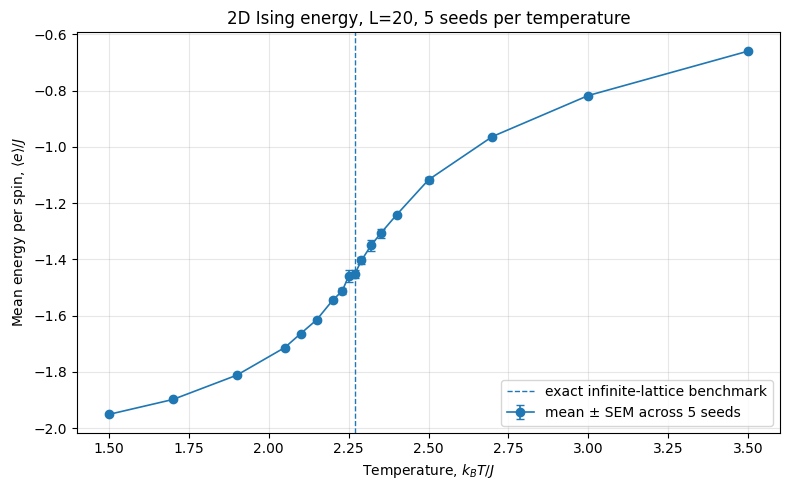

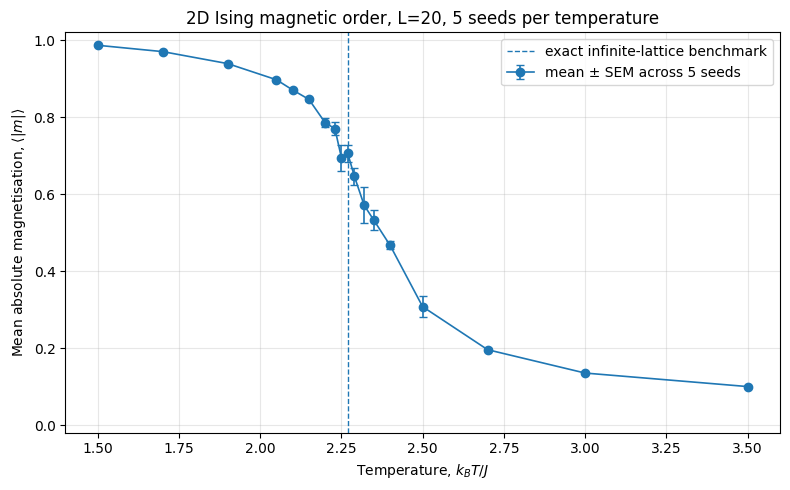

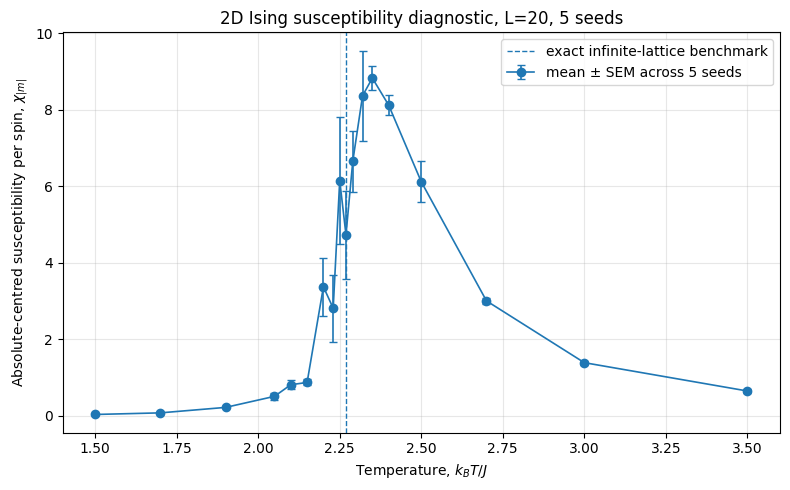

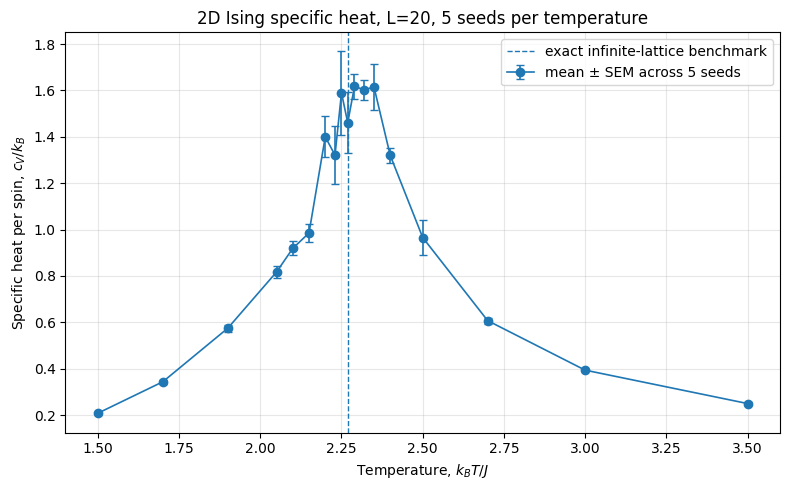

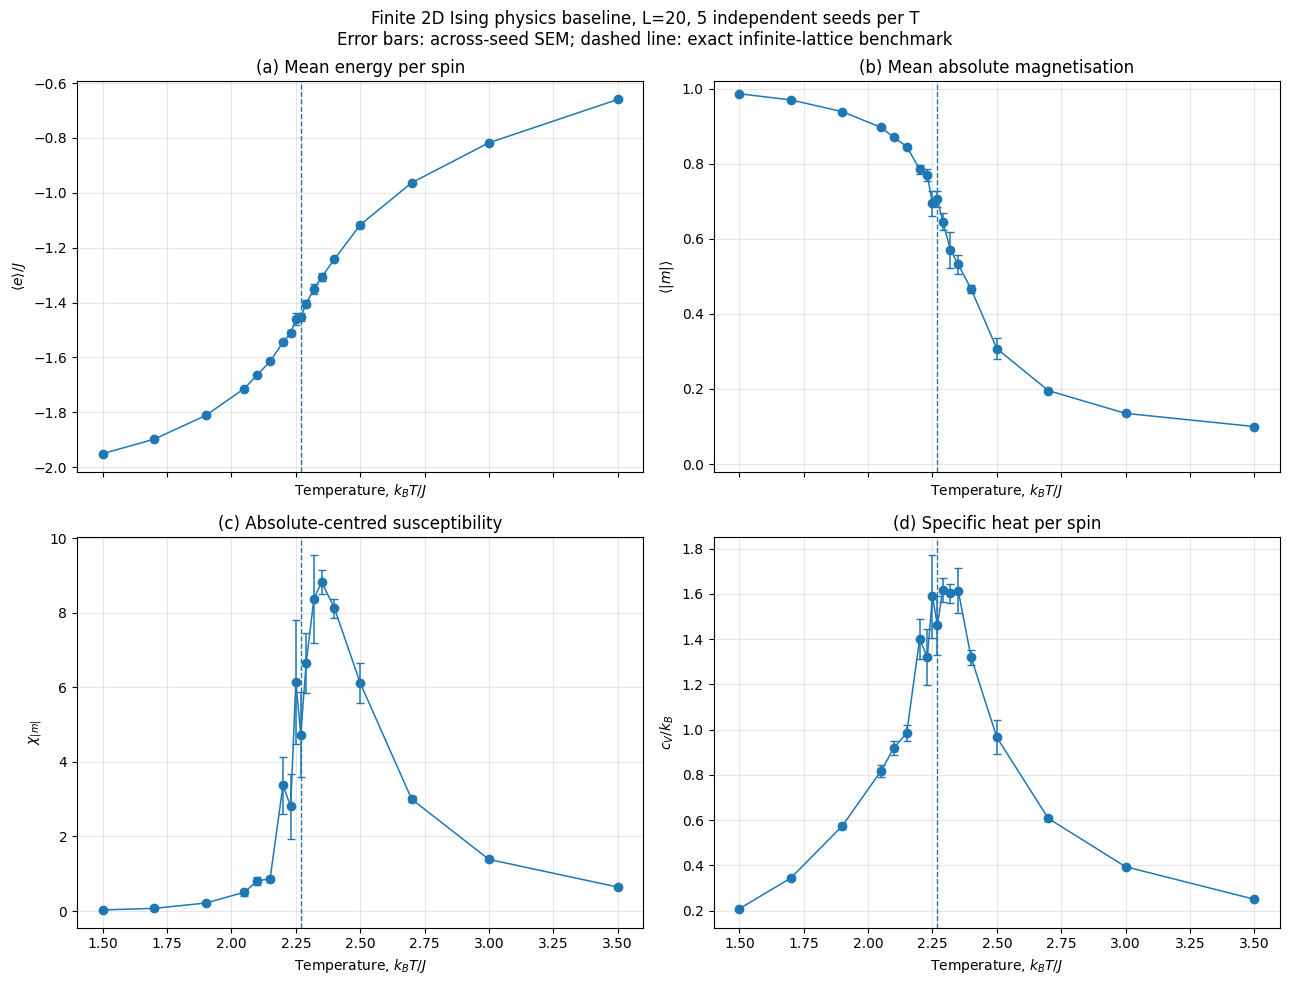

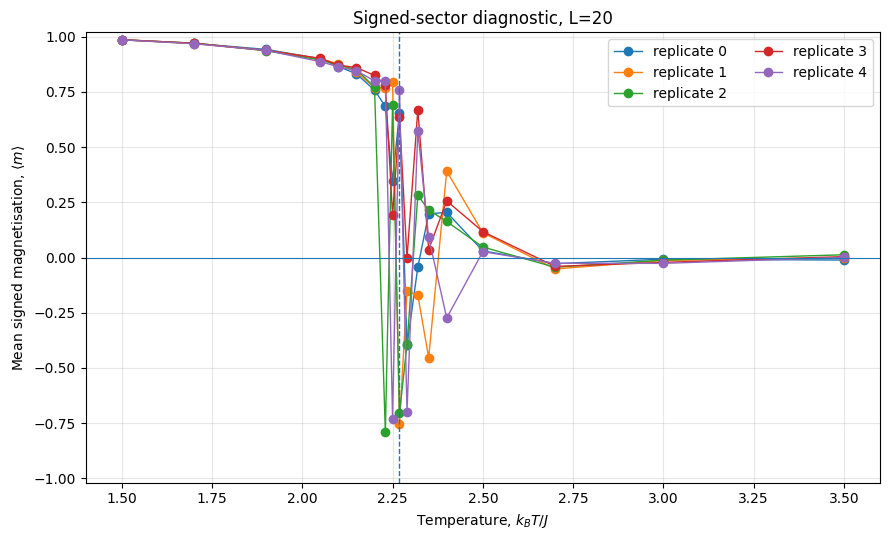

Saved figures:
  C:\Dev\Masters Project\figures\exploratory\classical\day23\energy_per_spin_vs_temperature_L20_R5.png
  C:\Dev\Masters Project\figures\exploratory\classical\day23\absolute_magnetisation_vs_temperature_L20_R5.png
  C:\Dev\Masters Project\figures\exploratory\classical\day23\susceptibility_absolute_centred_vs_temperature_L20_R5.png
  C:\Dev\Masters Project\figures\exploratory\classical\day23\specific_heat_per_spin_vs_temperature_L20_R5.png
  C:\Dev\Masters Project\figures\exploratory\classical\day23\physics_baseline_2x2_L20_R5.png
  C:\Dev\Masters Project\figures\exploratory\classical\day23\signed_magnetisation_sector_diagnostic_L20_R5.png


In [8]:
def save_errorbar_plot_notebook(
    table: pd.DataFrame,
    *,
    mean_column: str,
    sem_column: str,
    ylabel: str,
    title: str,
    output_path: Path,
    ylim: tuple[float, float] | None = None,
) -> None:
    """Save one consistent observable plot."""
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.errorbar(
        table["temperature"],
        table[mean_column],
        yerr=table[sem_column],
        fmt="o-",
        linewidth=1.2,
        capsize=3,
        label=f"mean ± SEM across {n_replicates} seeds",
    )
    axis.axvline(
        TC_EXACT,
        linestyle="--",
        linewidth=1.0,
        label="exact infinite-lattice benchmark",
    )
    axis.set_xlabel(r"Temperature, $k_B T/J$")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    if ylim is not None:
        axis.set_ylim(*ylim)
    axis.grid(True, alpha=0.3)
    axis.legend()
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)


L = int(main_sweep["lattice_size"])
R = int(main_sweep["n_replicates"])

energy_path = FIGURE_DIR / f"energy_per_spin_vs_temperature_L{L}_R{R}.png"
magnetisation_path = (
    FIGURE_DIR / f"absolute_magnetisation_vs_temperature_L{L}_R{R}.png"
)
susceptibility_path = (
    FIGURE_DIR
    / f"susceptibility_absolute_centred_vs_temperature_L{L}_R{R}.png"
)
specific_heat_path = (
    FIGURE_DIR / f"specific_heat_per_spin_vs_temperature_L{L}_R{R}.png"
)
combined_path = FIGURE_DIR / f"physics_baseline_2x2_L{L}_R{R}.png"
sector_path = (
    FIGURE_DIR / f"signed_magnetisation_sector_diagnostic_L{L}_R{R}.png"
)

save_errorbar_plot_notebook(
    aggregate_summary,
    mean_column="mean_energy_per_spin_mean",
    sem_column="mean_energy_per_spin_sem",
    ylabel=r"Mean energy per spin, $\langle e\rangle/J$",
    title=f"2D Ising energy, L={L}, {R} seeds per temperature",
    output_path=energy_path,
)

save_errorbar_plot_notebook(
    aggregate_summary,
    mean_column="mean_absolute_magnetisation_mean",
    sem_column="mean_absolute_magnetisation_sem",
    ylabel=r"Mean absolute magnetisation, $\langle |m|\rangle$",
    title=f"2D Ising magnetic order, L={L}, {R} seeds per temperature",
    output_path=magnetisation_path,
    ylim=(-0.02, 1.02),
)

save_errorbar_plot_notebook(
    aggregate_summary,
    mean_column="susceptibility_absolute_centred_per_spin_mean",
    sem_column="susceptibility_absolute_centred_per_spin_sem",
    ylabel=r"Absolute-centred susceptibility per spin, $\chi_{|m|}$",
    title=f"2D Ising susceptibility diagnostic, L={L}, {R} seeds",
    output_path=susceptibility_path,
)

save_errorbar_plot_notebook(
    aggregate_summary,
    mean_column="specific_heat_per_spin_mean",
    sem_column="specific_heat_per_spin_sem",
    ylabel=r"Specific heat per spin, $c_V/k_B$",
    title=f"2D Ising specific heat, L={L}, {R} seeds per temperature",
    output_path=specific_heat_path,
)

figure, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True)
panels = (
    (
        axes[0, 0],
        "mean_energy_per_spin_mean",
        "mean_energy_per_spin_sem",
        r"$\langle e\rangle/J$",
        "(a) Mean energy per spin",
    ),
    (
        axes[0, 1],
        "mean_absolute_magnetisation_mean",
        "mean_absolute_magnetisation_sem",
        r"$\langle |m|\rangle$",
        "(b) Mean absolute magnetisation",
    ),
    (
        axes[1, 0],
        "susceptibility_absolute_centred_per_spin_mean",
        "susceptibility_absolute_centred_per_spin_sem",
        r"$\chi_{|m|}$",
        "(c) Absolute-centred susceptibility",
    ),
    (
        axes[1, 1],
        "specific_heat_per_spin_mean",
        "specific_heat_per_spin_sem",
        r"$c_V/k_B$",
        "(d) Specific heat per spin",
    ),
)

for axis, mean_column, sem_column, ylabel, title in panels:
    axis.errorbar(
        aggregate_summary["temperature"],
        aggregate_summary[mean_column],
        yerr=aggregate_summary[sem_column],
        fmt="o-",
        linewidth=1.1,
        capsize=3,
    )
    axis.axvline(TC_EXACT, linestyle="--", linewidth=1.0)
    axis.set_xlabel(r"Temperature, $k_B T/J$")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.grid(True, alpha=0.3)

axes[0, 1].set_ylim(-0.02, 1.02)
figure.suptitle(
    f"Finite 2D Ising physics baseline, L={L}, {R} independent seeds per T\n"
    "Error bars: across-seed SEM; dashed line: exact infinite-lattice benchmark"
)
figure.tight_layout()
figure.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)

figure, axis = plt.subplots(figsize=(9, 5.5))
for replicate_index in range(R):
    replicate_table = chain_observables[
        chain_observables["replicate"] == replicate_index
    ]
    axis.plot(
        replicate_table["temperature"],
        replicate_table["mean_signed_magnetisation"],
        marker="o",
        linewidth=1.0,
        label=f"replicate {replicate_index}",
    )
axis.axhline(0.0, linewidth=0.8)
axis.axvline(TC_EXACT, linestyle="--", linewidth=1.0)
axis.set_xlabel(r"Temperature, $k_B T/J$")
axis.set_ylabel(r"Mean signed magnetisation, $\langle m\rangle$")
axis.set_title(f"Signed-sector diagnostic, L={L}")
axis.set_ylim(-1.02, 1.02)
axis.grid(True, alpha=0.3)
axis.legend(ncol=2)
figure.tight_layout()
figure.savefig(sector_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)

print("Saved figures:")
for path in (
    energy_path,
    magnetisation_path,
    susceptibility_path,
    specific_heat_path,
    combined_path,
    sector_path,
):
    print(f"  {path}")

## 8. Numerical extraction and stability diagnostics

The peak temperatures below are the largest values on the sampled finite-size grid. They are not presented as exact critical temperatures.

In [9]:
chi_peak = aggregate_summary.loc[
    aggregate_summary[
        "susceptibility_absolute_centred_per_spin_mean"
    ].idxmax()
]
cv_peak = aggregate_summary.loc[
    aggregate_summary["specific_heat_per_spin_mean"].idxmax()
]

peak_table = pd.DataFrame(
    [
        {
            "observable": "absolute-centred susceptibility per spin",
            "sampled_peak_temperature": float(chi_peak["temperature"]),
            "peak_mean": float(
                chi_peak[
                    "susceptibility_absolute_centred_per_spin_mean"
                ]
            ),
            "across_seed_sem": float(
                chi_peak[
                    "susceptibility_absolute_centred_per_spin_sem"
                ]
            ),
        },
        {
            "observable": "specific heat per spin",
            "sampled_peak_temperature": float(cv_peak["temperature"]),
            "peak_mean": float(cv_peak["specific_heat_per_spin_mean"]),
            "across_seed_sem": float(cv_peak["specific_heat_per_spin_sem"]),
        },
    ]
)

display(peak_table)

selected_temperatures = np.array([1.5, TC_EXACT, 3.5])
print(
    f"{'rep':>4} {'T':>10} {'e first':>11} {'e second':>11} "
    f"{'|m| first':>11} {'|m| second':>11} {'switches':>9}"
)
print("-" * 79)

for replicate_index in range(R):
    for target_temperature in selected_temperatures:
        temperature_index = int(
            np.argmin(
                np.abs(
                    np.asarray(main_sweep["temperatures"], dtype=float)
                    - target_temperature
                )
            )
        )
        temperature = float(main_sweep["temperatures"][temperature_index])
        energy_trace = (
            main_sweep["production_energy"][replicate_index, temperature_index]
            / int(main_sweep["n_spins"])
        )
        m_trace = main_sweep["production_magnetisation"][
            replicate_index,
            temperature_index,
        ]
        e_first, e_second = split_half_means(energy_trace)
        m_first, m_second = split_half_means(np.abs(m_trace))
        print(
            f"{replicate_index:>4d} {temperature:>10.6f} "
            f"{e_first:>11.5f} {e_second:>11.5f} "
            f"{m_first:>11.5f} {m_second:>11.5f} "
            f"{sector_switches_notebook(m_trace):>9d}"
        )

# Optional Day 22 comparison from actual saved values.
day22_path = (
    PROJECT_ROOT / "results" / "raw" / "ising_day22_temperature_sweep.npz"
)
if day22_path.exists():
    day22 = load_npz(day22_path)
    assert np.array_equal(day22["temperatures"], main_sweep["temperatures"])
    comparison = pd.DataFrame(
        {
            "temperature": main_sweep["temperatures"],
            "day22_energy_per_spin": np.mean(
                day22["mean_energy_per_spin"],
                axis=0,
            ),
            "day23_energy_per_spin": aggregate_summary[
                "mean_energy_per_spin_mean"
            ],
            "day22_absolute_magnetisation": np.mean(
                day22["mean_absolute_magnetisation"],
                axis=0,
            ),
            "day23_absolute_magnetisation": aggregate_summary[
                "mean_absolute_magnetisation_mean"
            ],
        }
    )
    display(comparison)
else:
    print(f"Day 22 comparison file not present: {day22_path}")

,observable,sampled_peak_temperature,peak_mean,across_seed_sem
0,absolute-centred susceptibility per spin,2.35,8.834144,0.319112
1,specific heat per spin,2.29,1.617717,0.053181


 rep          T     e first    e second   |m| first  |m| second  switches
-------------------------------------------------------------------------------
   0   1.500000    -1.95550    -1.94677     0.98794     0.98530         0
   0   2.269185    -1.41255    -1.47260     0.60972     0.73165        10
   0   3.500000    -0.67103    -0.66303     0.11069     0.10459       336
   1   1.500000    -1.95295    -1.94916     0.98706     0.98589         0
   1   2.269185    -1.46673    -1.48723     0.74257     0.76438         0
   1   3.500000    -0.66041    -0.65954     0.10185     0.09649       349
   2   1.500000    -1.94737    -1.95153     0.98538     0.98654         0
   2   2.269185    -1.44285    -1.45930     0.70968     0.70260         0
   2   3.500000    -0.65117    -0.66007     0.10270     0.09611       329
   3   1.500000    -1.95239    -1.95164     0.98694     0.98669         0
   3   2.269185    -1.39421    -1.41513     0.62113     0.67014         2
   3   3.500000    -0.65921    -

,temperature,day22_energy_per_spin,day23_energy_per_spin,day22_absolute_magnetisation,day23_absolute_magnetisation
0,1.500000,-1.951075,-1.950578,0.986545,0.986344
1,1.700000,-1.901190,-1.897718,0.970908,0.969898
2,1.900000,-1.813380,-1.811356,0.940375,0.938762
3,2.050000,-1.696200,-1.713280,0.880540,0.896838
4,2.100000,-1.636970,-1.663516,0.819492,0.870243
5,2.150000,-1.628880,-1.614625,0.857318,0.845798
6,2.200000,-1.558665,-1.545094,0.807880,0.785116
7,2.230000,-1.473840,-1.511786,0.678655,0.769779
8,2.250000,-1.483895,-1.459484,0.734548,0.694281
9,2.269185,-1.436690,-1.452277,0.683973,0.706504


## 9. Promotion check: notebook prototypes versus reusable code

This small parity test checks that the promoted code reproduces the tested notebook implementation.

In [10]:
from ising2d.dataset import (
    make_seed_matrix as make_seed_matrix_promoted,
    run_temperature_sweep as run_temperature_sweep_promoted,
)
from ising2d.observables import (
    specific_heat as specific_heat_promoted,
    susceptibility as susceptibility_promoted,
)

assert np.array_equal(
    make_seed_matrix_notebook(23000, 5, 18),
    make_seed_matrix_promoted(23000, 5, 18),
)
assert np.isclose(
    specific_heat_notebook(toy_energy, temperature=2.0, n_spins=4),
    specific_heat_promoted(toy_energy, temperature=2.0, n_spins=4),
)
for centre in ("signed", "absolute"):
    assert np.isclose(
        susceptibility_notebook(
            toy_m,
            temperature=2.0,
            n_spins=4,
            centre=centre,
        ),
        susceptibility_promoted(
            toy_m,
            temperature=2.0,
            n_spins=4,
            centre=centre,
        ),
    )

# Compare the promoted sweep on the fast smoke configuration.
promoted_smoke = run_temperature_sweep_promoted(
    **smoke_parameters,
    verbose=False,
)
for field_name in (
    "seeds",
    "initial_lattice",
    "final_lattice",
    "production_energy",
    "production_magnetisation",
    "production_acceptance",
):
    assert np.array_equal(smoke_a[field_name], promoted_smoke[field_name])

print("Promotion parity checks passed.")

Promotion parity checks passed.


### Limitations

- Five chains provide provisional across-seed uncertainty, not a final phase-boundary interval.
- Samples within each chain are autocorrelated.
- The susceptibility and specific-heat maxima are finite-size and grid-dependent sampled peaks.
- One lattice size cannot establish the thermodynamic-limit transition.
- The exact line is an infinite-lattice benchmark.